In [16]:
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms


In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
# run once to get 64 x 64 imgs
# images = np.load("kanji_images.npy", mmap_mode="r")
# resized = np.empty((len(images), 64, 64), dtype=np.uint8)

# for i in range(len(images)):
#     img = Image.fromarray(images[i]).resize((64, 64), Image.BILINEAR)
#     resized[i] = np.array(img)

# np.save("kanji_images_64.npy", resized)

In [22]:
from torch.utils.data import Dataset, DataLoader

# batch & normalizing

class KanjiDataset(Dataset):
    def __init__(self, image_file, label_file, indices):
        self.images = np.load(image_file, mmap_mode="r")
        self.labels = np.load(label_file, mmap_mode="r")
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        image = torch.from_numpy(self.images[real_idx].copy()).float().div(255.0).unsqueeze(0)
        label = torch.tensor(self.labels[real_idx]).long()

        return image, label

In [23]:
from sklearn.model_selection import train_test_split

# train test split
class_list = np.load("class_list.npy")
y = np.load("kanji_labels.npy")

indices = np.arange(len(y))
train_idx, temp_idx = train_test_split(indices, test_size=0.2, stratify=y, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=y[temp_idx], random_state=42)


In [49]:
train_data = KanjiDataset("kanji_images_64.npy", "kanji_labels.npy", train_idx)
val_data = KanjiDataset("kanji_images_64.npy", "kanji_labels.npy", val_idx)
test_data = KanjiDataset( "kanji_images_64.npy", "kanji_labels.npy", test_idx)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False, num_workers=0, pin_memory=True)

In [50]:
image, label = train_data[0]
print(image.size())
print(len(class_list))

torch.Size([1, 64, 64])
3036


In [51]:
class NeuralNet(nn.Module):

    # blocks = 3x3 conv, 

    def __init__(self, num_classes=3036, input_size=64):
        super().__init__()

        self.features = nn.Sequential(
            # block 1
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # block 2
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # block 3
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        # infer flatten size
        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_size, input_size)
            flat_size = self.features(dummy).flatten(1).shape[1]

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, 512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, num_classes),
        )


    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [52]:
net = NeuralNet().to(device)
loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

In [ ]:
train_losses, val_losses, val_accuracies = [], [], []
for epoch in range(10):
    print(f'Training epoch {epoch}...')

    running_loss = 0.0

    for i, data in enumerate(train_loader):
        inputs, labels = data

        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = net(inputs)

        loss = loss_function(outputs, labels)
        loss.backward() # backward propagation
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    print(f'Loss: {running_loss / len(train_loader):.4f}')

    # validation
    net.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)
            loss = loss_function(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(100 * val_correct / val_total)

    print(f'Val Loss: {val_loss/len(val_loader):.4f}, Val Accuracy: {100*val_correct/val_total:.2f}%')
    scheduler.step(val_loss / len(val_loader))
    net.train()

Training epoch 0...
Loss: 7.9358
Val Loss: 7.3173, Val Accuracy: 1.06%
Training epoch 1...
Loss: 4.5802
Val Loss: 1.1285, Val Accuracy: 81.14%
Training epoch 2...
Loss: 0.9401
Val Loss: 0.2388, Val Accuracy: 95.77%
Training epoch 3...
Loss: 0.3783
Val Loss: 0.1237, Val Accuracy: 97.47%
Training epoch 4...
Loss: 0.2337
Val Loss: 0.1460, Val Accuracy: 96.73%
Training epoch 5...
Loss: 0.1688
Val Loss: 0.1749, Val Accuracy: 96.25%
Training epoch 6...
Loss: 0.1303
Val Loss: 0.0866, Val Accuracy: 97.96%
Training epoch 7...
Loss: 0.1074
Val Loss: 0.2446, Val Accuracy: 93.56%
Training epoch 8...
Loss: 0.0901
Val Loss: 0.0419, Val Accuracy: 99.02%
Training epoch 9...
Loss: 0.0773
Val Loss: 0.0372, Val Accuracy: 99.12%


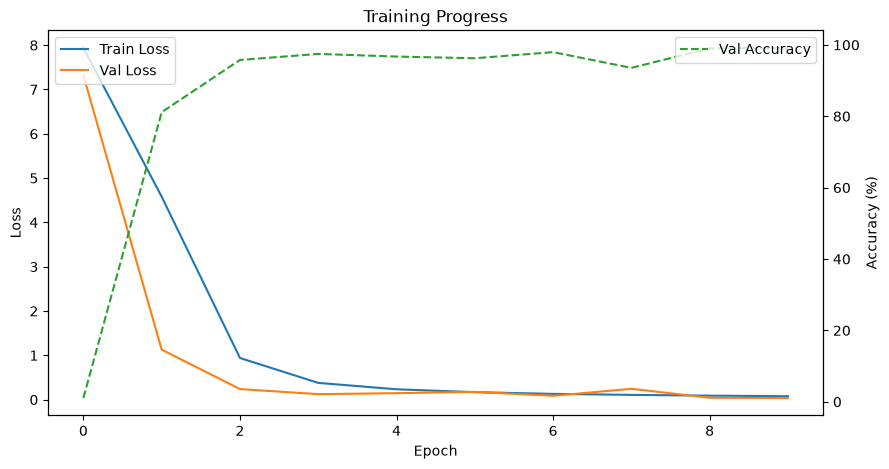

In [54]:
# plot
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(train_losses, label='Train Loss', color='tab:blue')
ax1.plot(val_losses, label='Val Loss', color='tab:orange')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(val_accuracies, label='Val Accuracy', color='tab:green', linestyle='--')
ax2.set_ylabel('Accuracy (%)')
ax2.legend(loc='upper right')

plt.title('Training Progress')
plt.show()

In [ ]:
# export model parameters
torch.save(net.state_dict(), 'kanji_model.pth')

In [ ]:
net = NeuralNet().to(device)
net.load_state_dict(torch.load('kanji_model.pth', map_location=device))

In [ ]:
# eval on test data

correct = 0
total = 0

net.eval()

# feed data in to get predictions and compare to labels
with torch.no_grad():
    for data in test_loader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f'Accuracy: {accuracy}%')